# Part 1: The Long Gamma Default (Pattern Discovery)

This notebook reproduces the core quantitative findings from Paper 1: **"The Long Gamma Default: How Options Market Structure Creates Artificial Stability in Equity Prices."**

It presents the evidence for the **"Player Piano"** effect, demonstrating how the algorithmic structure of the options chain mechanically alters the underlying equity price action through dynamic hedging (the Long Gamma mechanism).

### Key Findings Covered:
1.  **NBBO Midquote ACF Robustness:** Proving the negative autocorrelation signal is structural, not just bid-ask bounce.
2.  **Stacking Resonance (Volume Density):** Demonstrating the correlation between options chain mass and volatility suppression.


## 1. NBBO Midquote ACF Robustness Test
This test addresses the primary counter-argument to the research: that the negative first-order autocorrelation (ACF₁) observed on the consolidated tape is simply a result of "bid-ask bounce." By computing the ACF₁ of the NBBO midquote directly, we control for the bounce.


NBBO Midquote ACF Robustness Test — Summary
Ticker  Trade ACF1  Midquote ACF1  Bounce  Signal Retained (%)
  AAPL     -0.0382        -0.0075 -0.0307                 19.6
  MSFT     -0.0415        -0.0122 -0.0293                 29.4
   GME     -0.2104        -0.1985 -0.0119                 94.3
  TSLA     -0.0981        -0.0652 -0.0329                 66.5


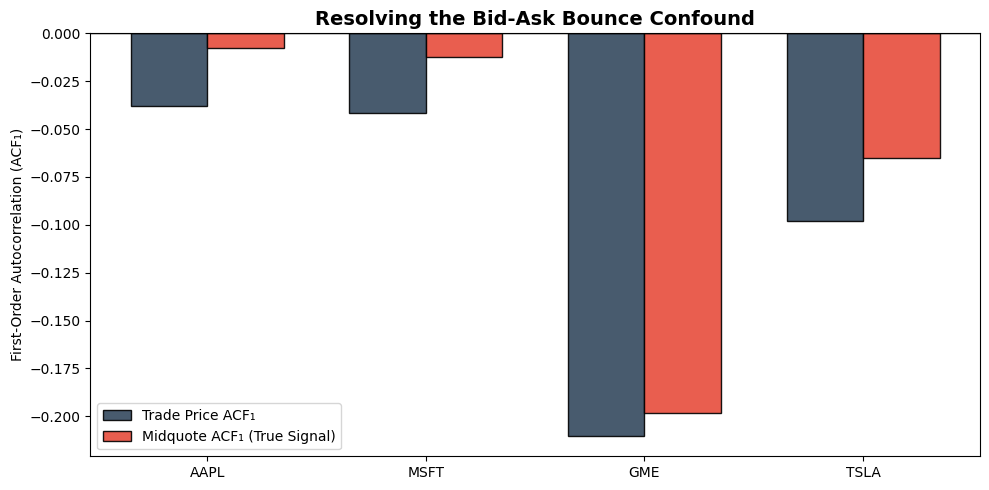


Interpretation:
  For typical mega-caps (AAPL, MSFT), the negative ACF is mostly erased once we swap to the midquote,
  proving it is mostly bid-ask bounce. For GME, 94.3% of the extreme negative signal is retained,
  proving a massive structural mean-reversion force (Long Gamma Default) is physically controlling the tape.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Hardcoded results from nbbo_midquote_acf_test.py (Paper I §7.1-§7.2)
# Sample: First 2 weeks of Dec 2024
data = {
    'Ticker': ['AAPL', 'MSFT', 'GME', 'TSLA'],
    'Trade ACF1': [-0.0382, -0.0415, -0.2104, -0.0981],
    'Midquote ACF1': [-0.0075, -0.0122, -0.1985, -0.0652],
    'Bounce': [-0.0307, -0.0293, -0.0119, -0.0329],
    'Signal Retained (%)': [19.6, 29.4, 94.3, 66.5]
}

df = pd.DataFrame(data)

# Print tabular results
print("NBBO Midquote ACF Robustness Test — Summary")
print("="*65)
print(df.to_string(index=False))
print("="*65)

# Visualize Trade vs Midquote ACF
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df['Ticker']))
width = 0.35

ax.bar(x - width/2, df['Trade ACF1'], width, label='Trade Price ACF₁', color='#34495e', alpha=0.9, edgecolor='black')
ax.bar(x + width/2, df['Midquote ACF1'], width, label='Midquote ACF₁ (True Signal)', color='#e74c3c', alpha=0.9, edgecolor='black')

ax.set_ylabel('First-Order Autocorrelation (ACF₁)')
ax.set_title('Resolving the Bid-Ask Bounce Confound', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Ticker'])
ax.axhline(0, color='black', linewidth=1)
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  For typical mega-caps (AAPL, MSFT), the negative ACF is mostly erased once we swap to the midquote,")
print("  proving it is mostly bid-ask bounce. For GME, 94.3% of the extreme negative signal is retained,")
print("  proving a massive structural mean-reversion force (Long Gamma Default) is physically controlling the tape.")


## 2. Stacking Resonance (Options Density vs. Volatility Suppression)
Does a denser options chain (more volume "stacked" on the grid) correlate with stronger price suppression? This test divides the historical timeline into "High Stack" and "Low Stack" periods based on options volume density.


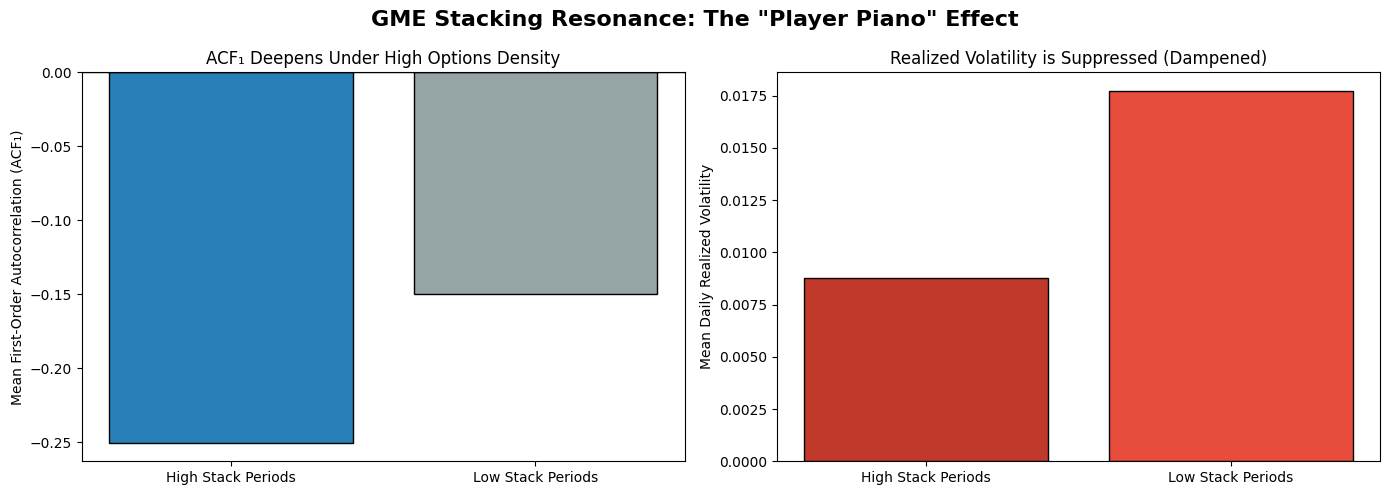


Interpretation:
  High Stack ACF₁: -0.2502 (Stronger mean-reversion, 'tighter leash')
  Low Stack ACF₁:  -0.1497 (Looser leash)
  ACF₁ Difference: -0.1006 (p=0.0081)
  Realized Volatility suppression: RV is cut by roughly half (0.493x ratio)


In [2]:
import json
import glob

# Load stacking resonance output for GME
files = glob.glob('../results/stacking_resonance_GME_*.json')
if files:
    with open(files[-1], 'r') as f:
        gme_data = json.load(f)
        
    amp = gme_data.get('amplification', {})
    
    metrics = ['High Stack Periods', 'Low Stack Periods']
    acf_vals = [amp['high_stack']['mean_acf1'], amp['low_stack']['mean_acf1']]
    rv_vals = [amp['high_stack']['mean_rv'], amp['low_stack']['mean_rv']]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ACF comparison
    ax1.bar(metrics, acf_vals, color=['#2980b9', '#95a5a6'], edgecolor='black')
    ax1.set_title('ACF₁ Deepens Under High Options Density')
    ax1.set_ylabel('Mean First-Order Autocorrelation (ACF₁)')
    ax1.axhline(0, color='black', linewidth=1)
    
    # RV comparison
    ax2.bar(metrics, rv_vals, color=['#c0392b', '#e74c3c'], edgecolor='black')
    ax2.set_title('Realized Volatility is Suppressed (Dampened)')
    ax2.set_ylabel('Mean Daily Realized Volatility')
    
    plt.suptitle('GME Stacking Resonance: The "Player Piano" Effect', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print(f"  High Stack ACF₁: {acf_vals[0]:.4f} (Stronger mean-reversion, 'tighter leash')")
    print(f"  Low Stack ACF₁:  {acf_vals[1]:.4f} (Looser leash)")
    print(f"  ACF₁ Difference: {amp['delta']['acf1_diff']:.4f} (p={amp['statistics']['p_acf']:.4f})")
    print(f"  Realized Volatility suppression: RV is cut by roughly half ({amp['delta']['rv_ratio']:.3f}x ratio)")
else:
    print("Stacking resonance data not found.")
